# Sistem Prediksi Rating Bintang Aplikasi Game Berdasarkan Analisis Sentimen Ulasan Menggunakan Metode Long Short-Term Memory (LSTM)

**Alur Tahapan:**
1. Persiapan Alat & Load Data
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Text Preprocessing
4. Translasi ke Bahasa Mesin & Splitting Data
5. Pelatihan Model LSTM & Evaluasi
6. Ekspor Model untuk Deployment

### 1. Import Library
Menyiapkan semua Library yang dibutuhkan. Kita menggunakan **Pandas** (untuk manipulasi tabel data), **NLTK & Sastrawi** (untuk pemrosesan teks bahasa Indonesia), serta **TensorFlow/Keras** (untuk membangun arsitektur *machine learning* LSTM).

In [3]:
import pandas as pd
import numpy as np
import re
import glob
import pickle
import tensorflow as tf
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import emoji 
import tensorflow as tf

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

Tokenizer = tf.keras.preprocessing.text.Tokenizer
pad_sequences = tf.keras.preprocessing.sequence.pad_sequences

Sequential = tf.keras.Sequential

Embedding = tf.keras.layers.Embedding
LSTM = tf.keras.layers.LSTM
Dense = tf.keras.layers.Dense
Dropout = tf.keras.layers.Dropout

Adam = tf.keras.optimizers.Adam

from wordcloud import WordCloud

print("Semua library berhasil dimuat!")

Semua library berhasil dimuat!


### 2. Load Dataset
Mengambil dan menggabungkan semua file CSV hasil *scraping* (*Mobile Legends, Free Fire, eFootball*, dll.) ke dalam satu tabel data sentral (DataFrame) agar lebih efisien diproses secara bersamaan.

In [4]:
# Tambahkan 'Dataset/' di depan nama file
all_files = glob.glob("Dataset/dataset_review_*.csv")

df_list = []
for file in all_files:
    temp_df = pd.read_csv(file)
    # Sesuaikan juga replace-nya agar nama folder 'Dataset\' atau 'Dataset/' ikut terhapus di kolom source_app
    temp_df['source_app'] = file.replace('Dataset\\', '').replace('Dataset/', '').replace('dataset_review_', '').replace('.csv', '')
    df_list.append(temp_df)

# Menggabungkan jadi satu dataset utama
df = pd.concat(df_list, ignore_index=True)

print(f"Total data awal yang dimuat: {len(df)} baris")

Total data awal yang dimuat: 40000 baris


### 3. Data Understanding
Memeriksa struktur data, jumlah baris/kolom, dan distribusi kelas sentimen awal untuk memastikan tidak ada anomali yang parah sebelum diproses lebih lanjut.

In [5]:
print("Info Dataset:")
df.info()

print("\nDistribusi Sentimen Awal:")
print(df['sentiment'].value_counts())

print("\n5 Data Teratas:")
df.head()

Info Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   review_id      40000 non-null  str   
 1   review         40000 non-null  str   
 2   rating         40000 non-null  int64 
 3   sentiment      40000 non-null  str   
 4   likes          40000 non-null  int64 
 5   date           40000 non-null  str   
 6   reply_content  3691 non-null   object
 7   reply_date     3691 non-null   object
 8   source_app     40000 non-null  str   
dtypes: int64(2), object(2), str(5)
memory usage: 2.7+ MB

Distribusi Sentimen Awal:
sentiment
positif    23750
negatif    14111
netral      2139
Name: count, dtype: int64

5 Data Teratas:


,review_id,review,rating,sentiment,likes,date,reply_content,reply_date,source_app
0,275d6295-1064-4ac2-8ea5-f4756d741602,sangat bagus,5,positif,0,2026-06-22 11:21:00,NaN,NaN,eFootball
1,10eac18a-bce7-41de-8f3b-5ea463404b94,di dak bisa masuk ke dalam gemmmm,1,negatif,0,2026-06-22 11:16:38,NaN,NaN,eFootball
2,761cce69-d9bf-4a8e-8787-0c66e15e36c4,kualitas server.nya bapuk,1,negatif,0,2026-06-22 11:16:23,NaN,NaN,eFootball
3,f9f02fdb-b0de-4be9-b8eb-caa98c6873b8,akun saya tiba² hilang saat saya ingin mau ber...,1,negatif,1,2026-06-22 11:13:28,NaN,NaN,eFootball
4,91f73813-a176-462d-8f31-51707390516d,asik banget dan enak banget,5,positif,0,2026-06-22 11:12:48,NaN,NaN,eFootball


### 4. Exploratory Data Analysis (EDA)
Memvisualisasikan data mentah. Grafik *Countplot* menunjukkan perbandingan kuantitas ulasan positif vs negatif, sedangkan *WordCloud* memetakan kata-kata yang paling dominan muncul pada ulasan pemain.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18084\2049106007.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='sentiment', palette='viridis')


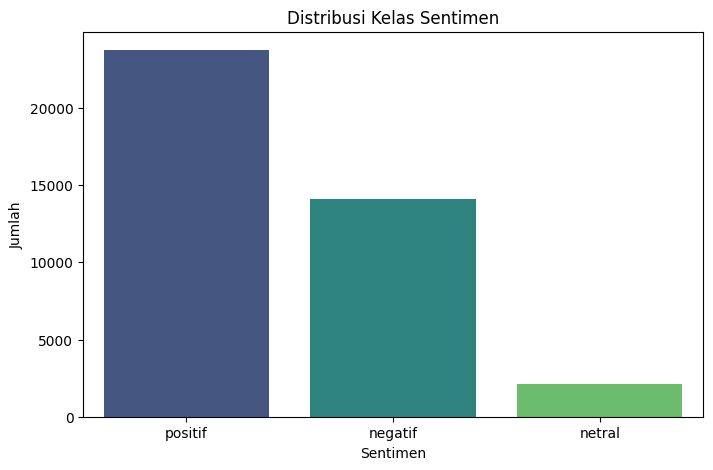

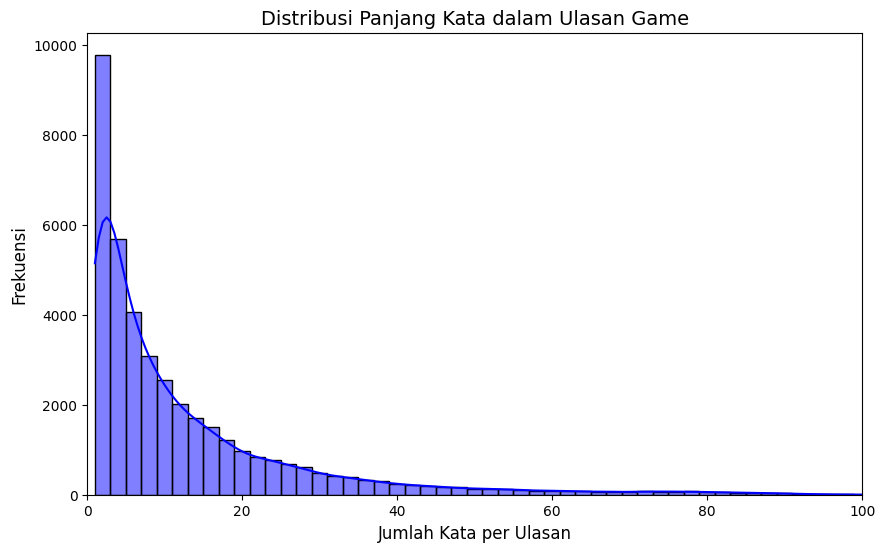

Rata-rata panjang ulasan: 12.41 kata
Panjang ulasan maksimal: 101 kata


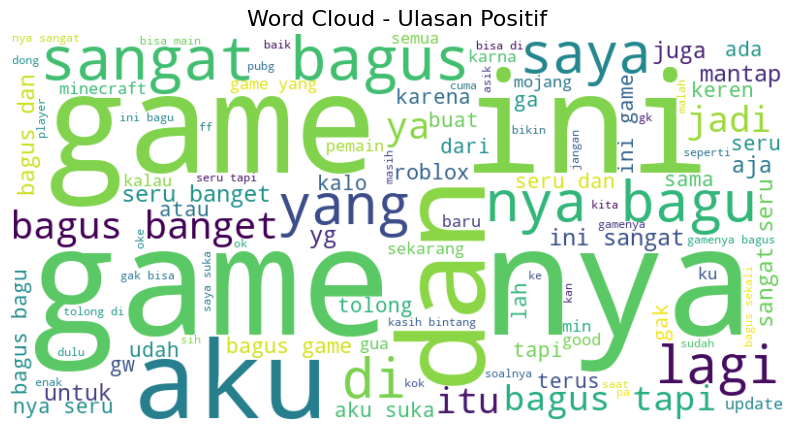

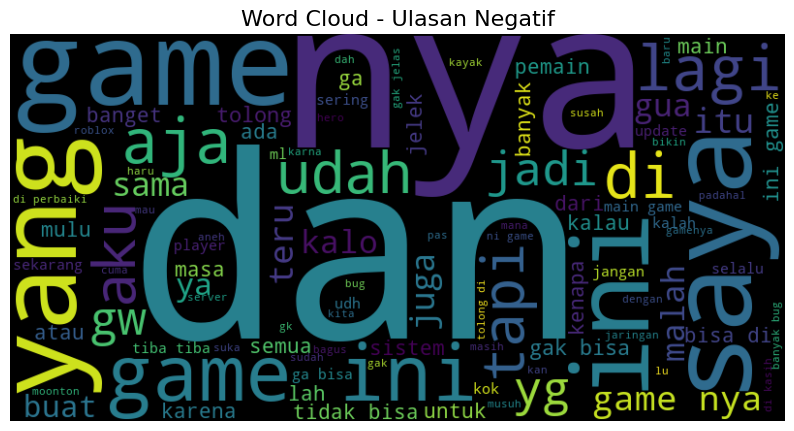

In [6]:
# Hapus missing values sementara untuk kebutuhan EDA
df_eda = df.dropna(subset=['review', 'sentiment']).copy()

# Distribusi Sentimen
plt.figure(figsize=(8, 5))
sns.countplot(data=df_eda, x='sentiment', palette='viridis')
plt.title('Distribusi Kelas Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

# Distribusi Panjang Teks Ulasan
df['panjang_teks'] = df['review'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['panjang_teks'], bins=50, kde=True, color='blue')
plt.title('Distribusi Panjang Kata dalam Ulasan Game', fontsize=14)
plt.xlabel('Jumlah Kata per Ulasan', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.xlim(0, 100) # Membatasi tampilan sumbu X agar lebih fokus
plt.show()

print(f"Rata-rata panjang ulasan: {df['panjang_teks'].mean():.2f} kata")
print(f"Panjang ulasan maksimal: {df['panjang_teks'].max()} kata")

from wordcloud import WordCloud

# Asumsi kolom sentimen/label bernama 'sentiment' dengan nilai 'positif' dan 'negatif'
teks_positif = ' '.join(df[df['sentiment'] == 'positif']['review'].astype(str))
teks_negatif = ' '.join(df[df['sentiment'] == 'negatif']['review'].astype(str))

# Fungsi pembantu untuk menampilkan WordCloud
def tampilkan_wordcloud(teks, judul, warna_background):
    wordcloud = WordCloud(width=800, height=400, background_color=warna_background, 
                        colormap='viridis', max_words=100).generate(teks)
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(judul, fontsize=16)
    plt.axis('off')
    plt.show()

# Menampilkan WordCloud Positif dan Negatif
tampilkan_wordcloud(teks_positif, 'Word Cloud - Ulasan Positif', 'white')
tampilkan_wordcloud(teks_negatif, 'Word Cloud - Ulasan Negatif', 'black')

### 5. Data Cleaning
Menghilangkan elemen *noise* (pengganggu) yang membingungkan mesin. Pada tahap ini kita menghapus URL, emoji, tanda baca, dan huruf berulang ("bangggeet" -> "banget"), serta menerjemahkan kata gaul (slang) menjadi kata baku menggunakan kamus modifikasi.

In [7]:
# Menghapus duplikasi dan missing values secara permanen
df.drop_duplicates(subset=['review_id'], inplace=True)
df.dropna(subset=['review', 'sentiment'], inplace=True)

# Kamus slang
slang_dict = {
    "yg": "yang", "dgn": "dengan", "bapuk": "jelek", "lemot": "lambat", 
    "tdk": "tidak", "ga": "tidak", "gk": "tidak", "gak": "tidak", 
    "bgs": "bagus", "mantap": "bagus", "gw": "saya", "sy": "saya", 
    "bgt": "banget", "knp": "kenapa", "klo": "kalau", "apk": "aplikasi",
    "afk": "keluar", "ngebug": "rusak", "bug": "rusak", "ngelag": "macet",
    "lag": "macet", "bocil": "anak kecil", "toxic": "kasar", "nerf": "lemah",
    "buff": "kuat", "op": "kuat", "bapuk": "jelek", "gemmmm": "game",
    "game": "permainan", "bintang 1": "sangat kecewa", "ilang": "hilang",
    "busuk": "jelek", "ngeframe": "macet"
}

def clean_data(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', str(text), flags=re.MULTILINE)
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1', text) 
    words = text.split()
    normalized_words = [slang_dict.get(word.lower(), word) for word in words]
    text = ' '.join(normalized_words)
    return re.sub(r'\s+', ' ', text).strip()

df['cleaned_text'] = df['review'].apply(clean_data)

### 6. Case Folding
Mengubah seluruh huruf menjadi huruf kecil (*lowercase*). Ini sangat krusial agar mesin tidak menganggap "Bagus" dan "bagus" sebagai dua entitas yang berbeda.

In [8]:
# Mengubah semua huruf menjadi huruf kecil (lowercase)
df['case_folded'] = df['cleaned_text'].str.lower()
df[['review', 'case_folded']].head()

,review,case_folded
0,sangat bagus,sangat bagus
1,di dak bisa masuk ke dalam gemmmm,di dak bisa masuk ke dalam gem
2,kualitas server.nya bapuk,kualitas servernya jelek
3,akun saya tiba² hilang saat saya ingin mau ber...,akun saya tiba hilang saat saya ingin mau berm...
4,asik banget dan enak banget,asik banget dan enak banget


### 7. Tokenizing
Memecah kalimat utuh menjadi potongan kata-kata individual (contoh: "game ini lemot" -> `["game", "ini", "lemot"]`).

In [9]:
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

print("Mendownload NLTK punkt...")
nltk.download('punkt', quiet=False)
nltk.download('punkt_tab', quiet=False)
warnings.filterwarnings('ignore')

# Proses Tokenisasi
df['tokenized'] = df['case_folded'].apply(lambda x: word_tokenize(x))

Mendownload NLTK punkt...


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### 8. Stopword Removal
Membuang kata hubung yang minim makna. 
**Penting (Keamanan Model):** Pada tahap ini kita menerapkan pengecualian ( *whitelist* ). Kata negasi seperti "tidak", "kurang", dan "jangan" HUKUMNYA WAJIB dipertahankan agar kalimat berkonteks negatif tidak memutarbalikkan fakta saat diolah oleh LSTM.

In [10]:
list_stopwords = set(stopwords.words('indonesian'))

# Pengecualian kata penting untuk konteks sentimen
exceptions = ["tidak", "jangan", "bukan", "kurang", "belum"]
for exc in exceptions:
    if exc in list_stopwords:
        list_stopwords.remove(exc)

def remove_stopwords(tokens):
    return [word for word in tokens if word not in list_stopwords]

df['stopword_removed'] = df['tokenized'].apply(remove_stopwords)

### 9. Stemming
Mengubah kata berimbuhan kembali ke akar dasarnya menggunakan pustaka Sastrawi (contoh: "memperbaiki" -> "baik"). Ini bertujuan untuk merampingkan variasi kosakata agar beban memori model lebih ringan.
*(Catatan: Proses ini memakan komputasi yang cukup lama).*

In [12]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming_process(tokens):
    text = ' '.join(tokens)
    return stemmer.stem(text)

print("Memulai proses Stemming... (Silakan tunggu)")
df['stemmed_text'] = df['stopword_removed'].apply(stemming_process)
print("Proses Stemming selesai!")

Memulai proses Stemming... (Silakan tunggu)
Proses Stemming selesai!


### 10. Label Encoding
Mesin komputer tidak bisa membaca teks sentimen ("Positif", "Negatif"). Tahap ini merubah teks tersebut menjadi kategori matematis (angka).

In [13]:
# Hapus baris yang menjadi kosong setelah di-stemming
df_final = df[df['stemmed_text'].str.strip() != ''].copy()

encoder = LabelEncoder()

df_final['label_encoded'] = encoder.fit_transform(df_final['sentiment'])

X = df_final['stemmed_text'].values
y = df_final['label_encoded'].values

print("Mapping Label sentimen:")
print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

Mapping Label sentimen:
{'negatif': np.int64(0), 'netral': np.int64(1), 'positif': np.int64(2)}


### 11. Train Test Split
Membagi total data menjadi tiga bagian utama menggunakan parameter *Stratified* agar proporsi kelas tetap seimbang:
* Train Set: Data untuk melatih model LSTM.
* Validation Set: Data evaluasi di tengah proses latihan untuk mencegah hafalan buta (*overfitting*).
* Test Set: Data ujian akhir.

In [14]:
# 1. Split pertama: Pisahkan Train (80%) dan Sisa (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

# 2. Split kedua: Pisahkan Sisa (20%) menjadi Validation (10%) dan Test (10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0, stratify=y_temp)

print(f"Jumlah Data Latih (Train): {len(X_train)} baris")
print(f"Jumlah Data Validasi (Val): {len(X_val)} baris")
print(f"Jumlah Data Uji (Test): {len(X_test)} baris")

Jumlah Data Latih (Train): 31529 baris
Jumlah Data Validasi (Val): 3941 baris
Jumlah Data Uji (Test): 3942 baris


### 12. Tokenizer LSTM & 13. Padding Sequence
* **Tokenizer:** Membuat kamus indeks kata berdasar data latih. Sangat penting melakukan *fitting* HANYA pada data latih untuk mencegah kecurangan (*Data Leakage*).
* **Padding:** Menyamaratakan seluruh kalimat ke panjang yang sama (ditambah angka 0 jika terlalu pendek, dipotong jika terlalu panjang) karena lapisan LSTM mewajibkan matriks berdimensi tetap.

In [15]:
VOCAB_SIZE = 10000
MAX_LENGTH = 60

# Inisialisasi dan Fitting Tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train) # Fitting HANYA pada data latih

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding Sequence
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

### 14. Membangun Arsitektur Model LSTM
Merangkai jaringan saraf tiruan. 
* **Embedding Layer:** Memetakan kedekatan konteks antar kata.
* **LSTM Layer:** Mengingat pola urutan waktu dari kalimat.
* **Dropout Layer:** Mematikan sebagian neuron secara acak untuk mencegah *overfitting*.
* **Dense Layer:** Lapisan output akhir pembentuk probabilitas sentimen.

In [16]:
from tensorflow.keras.layers import Input

model = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(VOCAB_SIZE, 128),
    LSTM(32),
    Dense(len(encoder.classes_), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,300,707 (4.96 MB)

 Trainable params: 1,300,707 (4.96 MB)

 Non-trainable params: 0 (0.00 B)

### 15. Training Model
Memulai proses belajar. Tahap ini diamankan oleh mekanisme **Early Stopping** (berhenti otomatis bila model tidak membaik setelah 3 tahap) dan **Model Checkpoint** (menyimpan otomatis bobot parameter di titik akurasi tertingginya).

In [17]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model_lstm.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5912 - loss: 0.8472
Epoch 1: val_loss improved from None to 0.83632, saving model to best_model_lstm.keras

Epoch 1: finished saving model to best_model_lstm.keras
493/493 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step - accuracy: 0.5893 - loss: 0.8403 - val_accuracy: 0.5897 - val_loss: 0.8363
Epoch 2/20
492/493 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6100 - loss: 0.8223
Epoch 2: val_loss improved from 0.83632 to 0.72301, saving model to best_model_lstm.keras

Epoch 2: finished saving model to best_model_lstm.keras
493/493 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.6562 - loss: 0.7808 - val_accuracy: 0.7227 - val_loss: 0.7230
Epoch 3/20
492/493 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7333 - loss: 0.7102
Epoch 3: val_loss improved from 0.72301 to 0.66426, saving model to best_model_lstm.keras

Epoch 3: finished saving model to best_model_lstm.keras
493/493 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.7420 -

### 16. Visualisasi Grafik Kurva Train Model (Loss & Accuracy Plot)

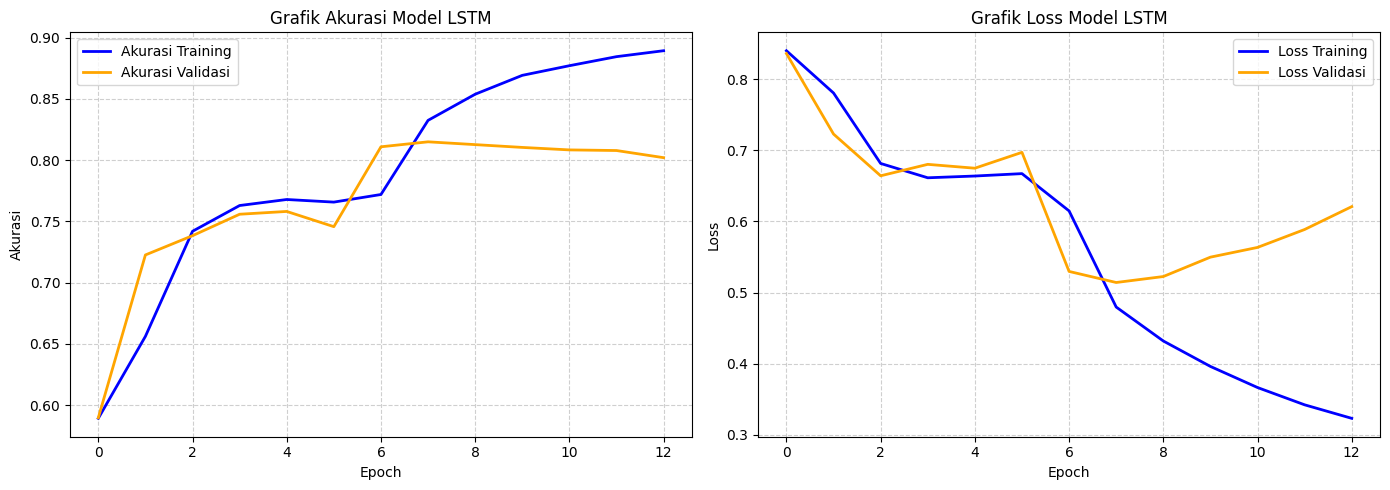

In [18]:
plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Akurasi Training', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Akurasi Validasi', color='orange', linewidth=2)
plt.title('Grafik Akurasi Model LSTM')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss (Fungsi Kerugian)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss Training', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Loss Validasi', color='orange', linewidth=2)
plt.title('Grafik Loss Model LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 17. Evaluasi Model
Model yang telah dilatih diberikan ujian akhir menggunakan Data Uji (*Test Set*). Sel ini mencetak metrik performa objektif (Akurasi, F1-Score) dan memunculkan *Confusion Matrix* untuk memetakan di area sentimen mana model masih kesulitan menebak.

124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
=== Hasil Evaluasi Model ===
Accuracy  : 0.8189
Precision : 0.7804
Recall    : 0.8189
F1-Score  : 0.7978



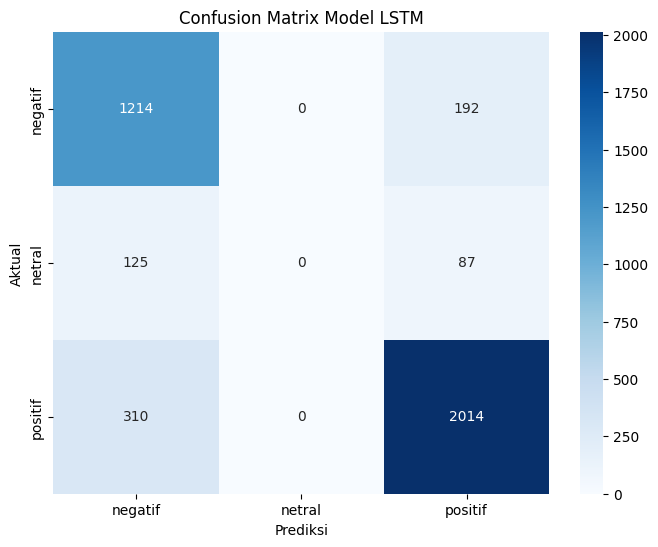


Laporan Klasifikasi Lengkap:

              precision    recall  f1-score   support

     negatif       0.74      0.86      0.79      1406
      netral       0.00      0.00      0.00       212
     positif       0.88      0.87      0.87      2324

    accuracy                           0.82      3942
   macro avg       0.54      0.58      0.56      3942
weighted avg       0.78      0.82      0.80      3942



In [19]:
# Lakukan prediksi pada Data Test
y_pred_prob = model.predict(X_test_padded)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

# Hitung Metrik Evaluasi Utama
acc = accuracy_score(y_test, y_pred_classes)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_classes, average='weighted')

print("=== Hasil Evaluasi Model ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title('Confusion Matrix Model LSTM')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# Classification Report Detail
print("\nLaporan Klasifikasi Lengkap:\n")
print(classification_report(y_test, y_pred_classes, target_names=encoder.classes_))

### 18-20. Export Model & Tools Preprocessing
Menyimpan model arsitektur LSTM, kamus kata (*Tokenizer*), dan kamus pengubah label (*Label Encoder*) ke dalam *file* fisik. Ketiga *file* inilah yang nantinya disuntikkan ke dalam REST API (seperti FastAPI) untuk aplikasi berbasis *web*.

In [20]:
model.save('model_sentimen_lstm_final.h5')
print("Model berhasil disimpan: model_sentimen_lstm_final.h5")

with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Tokenizer berhasil disimpan: tokenizer.pickle")

with open('label_encoder.pickle', 'wb') as handle:
    pickle.dump(encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Label Encoder berhasil disimpan: label_encoder.pickle")

Model berhasil disimpan: model_sentimen_lstm_final.h5
Tokenizer berhasil disimpan: tokenizer.pickle
Label Encoder berhasil disimpan: label_encoder.pickle
